In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# Load the dataset
df = pd.read_csv('dataset/balanced_fake_job_postings.csv')

# Display the first few rows to understand the structure
df.head()

,Job title,Job location,Department,Offered salary,Description of the company,Job description,Requirements/qualifications,Offered benefits,"Full-time, part-time, etc.",Experience required,Sector,Job function,fraudulent
0,Real Job Title 556,"New York, NY",HR,$3000/month,This is a reputable company profile for job 556.,This is a genuine job description for position...,Bachelor's degree and 2 years experience.,"Health insurance, PTO, 401k",Part-time,2 years,Information Technology,Software Engineering,0
1,Fake Job Title 1492,"New York, NY",HR,$5000/month,This is a fake company profile for job 1492.,This is a suspicious job description for posit...,No experience required,Unclear benefits,Part-time,NaN,Unknown,Clickbait Recruitment,1
2,Real Job Title 528,"New York, NY",HR,$3000/month,This is a reputable company profile for job 528.,This is a genuine job description for position...,Bachelor's degree and 2 years experience.,"Health insurance, PTO, 401k",Part-time,2 years,Information Technology,Software Engineering,0
3,Fake Job Title 1926,"New York, NY",HR,$5000/month,This is a fake company profile for job 1926.,This is a suspicious job description for posit...,No experience required,Unclear benefits,Part-time,NaN,Unknown,Clickbait Recruitment,1
4,Fake Job Title 990,"New York, NY",HR,$5000/month,This is a fake company profile for job 990.,This is a suspicious job description for posit...,No experience required,Unclear benefits,Part-time,NaN,Unknown,Clickbait Recruitment,1


In [13]:
import re
# Combine relevant text columns
df['text'] = (
    df['Job title'].fillna('') + ' ' +
    df['Job description'].fillna('') + ' ' +
    df['Requirements/qualifications'].fillna('') + ' ' +
    df['Description of the company'].fillna('')
)

# Clean the text data
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['text'] = df['text'].apply(clean_text)



In [14]:
# Define input (X) and output (y)
X = df['text']
y = df['fraudulent']  # Labels (0 = Fake, 1 = Real)

In [15]:
# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

In [16]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
model = RandomForestClassifier( n_estimators=300,max_depth=50,class_weight='balanced',random_state=42)

# Train the model
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=50, n_estimators=300,
                       random_state=42)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("✅ Model Evaluation Metrics")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")


✅ Model Evaluation Metrics
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [20]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test, y_pred, target_names=['Real', 'Fake'])
print("📊 Classification Report:\n")
print(report)

📊 Classification Report:

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       398
        Fake       1.00      1.00      1.00       402

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800




[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


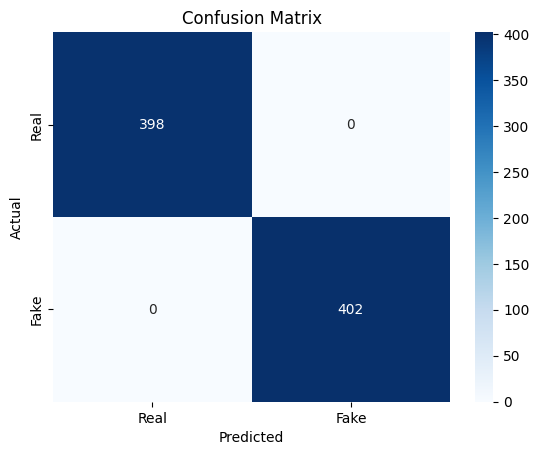

In [24]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
import pickle

# Save the model
with open('model/fake_job_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the vectorizer 
with open('model/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("✅ Random Forest model and vectorizer saved successfully!")


✅ Random Forest model and vectorizer saved successfully!
